In [59]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import pandas as pd
import os
from scipy.stats import chi2_contingency

In [60]:
df = pd.read_csv("../data/processed/csgo_cleaned_3.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 788324 entries, 0 to 788323
Data columns (total 32 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Unnamed: 0                788324 non-null  int64  
 1   map                       788324 non-null  str    
 2   round                     788324 non-null  int64  
 3   att_team                  788324 non-null  str    
 4   vic_team                  788324 non-null  str    
 5   att_side                  788324 non-null  str    
 6   vic_side                  788324 non-null  str    
 7   is_bomb_planted           788324 non-null  bool   
 8   bomb_site                 126079 non-null  str    
 9   wp                        788324 non-null  str    
 10  wp_type                   788324 non-null  str    
 11  winner_team               788324 non-null  str    
 12  winner_side               788324 non-null  str    
 13  att_pos_x                 788324 non-null  float64
 14 

In [61]:
from scipy import stats
import statsmodels.api as sm
import numpy as np

In [62]:
from pandas.api.types import CategoricalDtype

custom_order = CategoricalDtype(categories=['Silver', 'Gold Nova', 'Master Guardian', 'Top Four'], ordered=True)
df["att_tier"] = df["att_tier"].astype(custom_order)
df["vic_tier"] = df["vic_tier"].astype(custom_order)

We will later use the Cochran-Armitage (CA) test, but you will notice that the CA test is not used for att_tier vs. is_bomb_planted/round_type. This is because round_type and is_bomb_planted are variables that stay constant for extended amounts of time, and considering that the dataset considers each row as a damage entry, both variables violate independence assumptions. Hence, we use chi-squared test for independence.

In [63]:
ct = pd.crosstab(df["is_bomb_planted"], df["att_tier"])
ct

att_tier,Silver,Gold Nova,Master Guardian,Top Four
is_bomb_planted,,,,
False,14078,257466,292437,98264
True,2591,51805,53614,18069


In [64]:
chi2_stat, p_val, dof, expected_table = chi2_contingency(ct)
print(f"Chi-Square Statistic: {chi2_stat:.4f}")
print(f"P-Value:             {p_val:.8f}")
print(f"Degrees of Freedom:  {dof}")
print("\n--- Expected Frequencies Table ---")
print(pd.DataFrame(expected_table, index=ct.index, columns=ct.columns))

Chi-Square Statistic: 217.4095
P-Value:             0.00000000
Degrees of Freedom:  3

--- Expected Frequencies Table ---
att_tier               Silver      Gold Nova  Master Guardian      Top Four
is_bomb_planted                                                            
False            14003.077294  259808.369902    290706.035203  97727.517601
True              2665.922706   49462.630098     55344.964797  18605.482399


We can conclude that there is a relationship between the attacker's rank tier and whether the bomb is planted or not. This makes intuitive sense since players of different rank approach pressure differently.

In [65]:
ct = pd.crosstab(df["round_type"], df["att_tier"])
ct

att_tier,Silver,Gold Nova,Master Guardian,Top Four
round_type,,,,
ECO,3098,68412,97279,35699
FORCE_BUY,3213,52015,47756,14699
NORMAL,7519,140660,148912,48105
PISTOL_ROUND,1425,26458,28544,9715
SEMI_ECO,1414,21726,23560,8115


In [66]:
chi2_stat, p_val, dof, expected_table = chi2_contingency(ct)
print(f"Chi-Square Statistic: {chi2_stat:.4f}")
print(f"P-Value:             {p_val:.8f}")
print(f"Degrees of Freedom:  {dof}")
print("\n--- Expected Frequencies Table ---")
print(pd.DataFrame(expected_table, index=ct.index, columns=ct.columns))

Chi-Square Statistic: 5882.4061
P-Value:             0.00000000
Degrees of Freedom:  12

--- Expected Frequencies Table ---
att_tier           Silver      Gold Nova  Master Guardian      Top Four
round_type                                                             
ECO           4323.869972   80223.624104     89764.204677  30176.301247
FORCE_BUY     2488.390468   46168.756873     51659.368271  17366.484388
NORMAL        7299.120823  135425.424211    151530.869282  50940.585683
PISTOL_ROUND  1398.563279   25948.471037     29034.388452   9760.577232
SEMI_ECO      1159.055458   21504.723775     24062.169317   8089.051450


While we can conclude that there is a relationship between att_tier and round_type, we can't tell which round types have stronger trends across ranks. Top Four players may approach eco rounds more efficiently, while Silver players rely more on expensive weapons.

We're applying ANOVA to att_tier vs. total_dmg, so we will normalize total_dmg

In [67]:
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd


df["dmg_normalized"], optimal_lambda = stats.boxcox(df["total_dmg"])

dmg_normalized_1 = df.loc[df["att_tier"] == "Silver", "dmg_normalized"]
dmg_normalized_2 = df.loc[df["att_tier"] == "Gold Nova", "dmg_normalized"]
dmg_normalized_3 = df.loc[df["att_tier"] == "Master Guardian", "dmg_normalized"]
dmg_normalized_4 = df.loc[df["att_tier"] == "Top Four", "dmg_normalized"]

f_stat, p_val = stats.f_oneway(
    dmg_normalized_1, dmg_normalized_2, dmg_normalized_3, dmg_normalized_4
)
print(f"F-Statistic: {f_stat:.4f}, p-value: {p_val:.4e}")

tukey = pairwise_tukeyhsd(
    endog=df["dmg_normalized"],  # The normalized dependent variable
    groups=df["att_tier"],       # The categorical tier groups
    alpha=0.05                            # Significance level
)

print(tukey)

F-Statistic: 677.4387, p-value: 0.0000e+00
         Multiple Comparison of Means - Tukey HSD, FWER=0.05         
     group1          group2     meandiff p-adj  lower   upper  reject
---------------------------------------------------------------------
      Gold Nova Master Guardian   0.0674   0.0  0.0608   0.074   True
      Gold Nova          Silver  -0.0652   0.0 -0.0864 -0.0441   True
      Gold Nova        Top Four   0.1463   0.0  0.1372  0.1555   True
Master Guardian          Silver  -0.1326   0.0 -0.1537 -0.1115   True
Master Guardian        Top Four   0.0789   0.0  0.0699  0.0879   True
         Silver        Top Four   0.2115   0.0  0.1895  0.2336   True
---------------------------------------------------------------------


The ANOVA test confirms that there are differences between different rank tiers, thus giving us a green light to perform pairwise Tukey analysis, which gave us interesting results. Each pair had a statistically significant difference. However, we can't necessarily pinpoint what the difference in total_dmg is since we used Box-Cox normalization. Since all pairs had a statistically significant relationship, we can just look at the unormalized data and subtract means.

In [68]:
dmg_silver = df.loc[df["att_tier"] == "Silver", "total_dmg"]
dmg_gold = df.loc[df["att_tier"] == "Gold Nova", "total_dmg"]
dmg_master = df.loc[df["att_tier"] == "Master Guardian", "total_dmg"]
dmg_top = df.loc[df["att_tier"] == "Top Four", "total_dmg"]

print(f"Gold Nova --> Master Guardian Mean Difference: {np.mean(dmg_master) - np.mean(dmg_gold):.4f}")
print(f"Gold Nova --> Silver Mean Difference: {np.mean(dmg_silver) - np.mean(dmg_gold):.4f}")
print(f"Gold Nova --> Top Four Difference: {np.mean(dmg_top) - np.mean(dmg_gold):.4f}")
print(f"Master Guardian --> Silver Mean Difference: {np.mean(dmg_silver) - np.mean(dmg_master):.4f}")
print(f"Master Guardian --> Top Four Mean Difference: {np.mean(dmg_top) - np.mean(dmg_master):.4f}")
print(f"Silver --> Top Four Difference: {np.mean(dmg_top) - np.mean(dmg_silver):.4f}")

Gold Nova --> Master Guardian Mean Difference: 1.7830
Gold Nova --> Silver Mean Difference: -1.7759
Gold Nova --> Top Four Difference: 3.9769
Master Guardian --> Silver Mean Difference: -3.5589
Master Guardian --> Top Four Mean Difference: 2.1939
Silver --> Top Four Difference: 5.7528


We can interpret this the following way: on average, once you get from Gold Nova to Master Guardian, every instance you damage an opponent, you deal 1.7830 total damage more. This can be attributed to spray and recoil control, having better aim, etc.

We will now perform the Cochran-Armitage test for att_tier vs. wp:

In [69]:
# remove_list = ["Bomb", "Decoy", "Unknown"]
# chi_df = df[~df["wp"].isin(remove_list)]
ct = pd.crosstab(df["wp"], df["att_tier"])
ct

att_tier,Silver,Gold Nova,Master Guardian,Top Four
wp,,,,
AK47,3563,73907,94720,34238
AUG,375,4131,2226,337
AWP,452,12640,16684,6543
Bizon,341,3168,2233,459
CZ,103,2551,4479,2069
Deagle,253,7110,9957,4477
DualBarettas,49,793,660,121
Famas,405,6606,8391,2900
FiveSeven,208,5215,7620,2698


In [70]:
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests

df['att_tier_score'] = df['att_tier'].cat.codes

def cochran_armitage_trend(scores, n, r, alternative='greater'):
    scores, n, r = map(np.asarray, (scores, n, r))
    N = n.sum()
    R = r.sum()
    p_bar = R / N
    x_bar = (n * scores).sum() / N
    numerator = (n * (scores - x_bar) * (r / n - p_bar)).sum()
    denom = np.sqrt(p_bar * (1 - p_bar) * (n * (scores - x_bar) ** 2).sum())
    z = numerator / denom
    if alternative == 'greater':
        p_value = 1 - stats.norm.cdf(z)
    elif alternative == 'less':
        p_value = stats.norm.cdf(z)
    else:
        p_value = 2 * (1 - stats.norm.cdf(abs(z)))
    return z, p_value

def build_counts(df, group_col, outcome_col, outcome_value):
    n_total = df.groupby(group_col).size().rename('n_total')
    n_hit = (df[df[outcome_col] == outcome_value]
             .groupby(group_col).size()
             .rename('n_hit'))

    counts = pd.concat([n_total, n_hit], axis=1).fillna({'n_hit': 0})
    counts['n_hit'] = counts['n_hit'].astype(int)
    counts = counts.reset_index()
    counts['score'] = counts[group_col].cat.codes
    counts = counts.sort_values('score')
    return counts

def run_ca(counts, alternative='greater'):
    z, p = cochran_armitage_trend(counts['score'].values, counts['n_total'].values,
                                   counts['n_hit'].values, alternative=alternative)
    N = counts['n_total'].sum()
    effect_r = z / np.sqrt(N) if N > 0 else np.nan

    X = sm.add_constant(counts['score'].astype(float))
    y_prop = counts['n_hit'] / counts['n_total']
    try:
        model = sm.GLM(y_prop, X, family=sm.families.Binomial(),
                        freq_weights=counts['n_total'].values).fit()
        odds_ratio = np.exp(model.params['score'])
    except Exception:
        odds_ratio = np.nan

    return z, p, effect_r, odds_ratio

In [71]:
weapons = df['wp'].unique()
results = []

for wp in weapons:
    counts = build_counts(df, 'att_tier', 'wp', wp)
    if counts['n_hit'].sum() == 0 or counts['n_hit'].sum() == counts['n_total'].sum():
        continue  # skip degenerate cases: weapon never used, or used every single time
    z, p, effect_r, orr = run_ca(counts, alternative='greater')
    results.append({'wp': wp, 'z': z, 'p_raw': p, 'effect_r': effect_r,
                     'odds_ratio_per_tier': orr, 'counts': counts})

res_df = pd.DataFrame(results).dropna(subset=['p_raw'])
res_df['p_adj'] = multipletests(res_df['p_raw'], method='fdr_bh')[1]
res_df = res_df.sort_values('effect_r', ascending=False)
print(res_df.drop(columns='counts'))  # drop the nested counts table for a clean printout

              wp          z         p_raw  effect_r  odds_ratio_per_tier  \
9           AK47  43.343686  0.000000e+00  0.048817             1.162275   
0         Deagle  29.084723  0.000000e+00  0.032758             1.307179   
16          P250  28.689448  0.000000e+00  0.032312             1.283680   
2             CZ  27.819240  0.000000e+00  0.031332             1.476585   
5            AWP  24.983501  0.000000e+00  0.028138             1.197966   
12          M4A4  18.251265  0.000000e+00  0.020556             1.097365   
18     FiveSeven  17.334831  0.000000e+00  0.019524             1.206364   
17          Tec9   8.299495  0.000000e+00  0.009348             1.116950   
23         Famas   7.489737  3.452794e-14  0.008436             1.078666   
22         Swag7   6.426666  6.521628e-11  0.007238             1.124966   
13         Scout   6.325850  1.259213e-10  0.007125             1.105072   
6          P2000   0.759787  2.236911e-01  0.000856             1.011926   
10          

We can interpret this as follows: as you rank up, weapons that have a statistically significant result (such as AK47) will either become used more or less proportionally. The magnitude of such a trend is displayed by odds_ratio_per_tier. For better visualization, refer to the plots below (the plots only show weapons with a statistically significant trend).

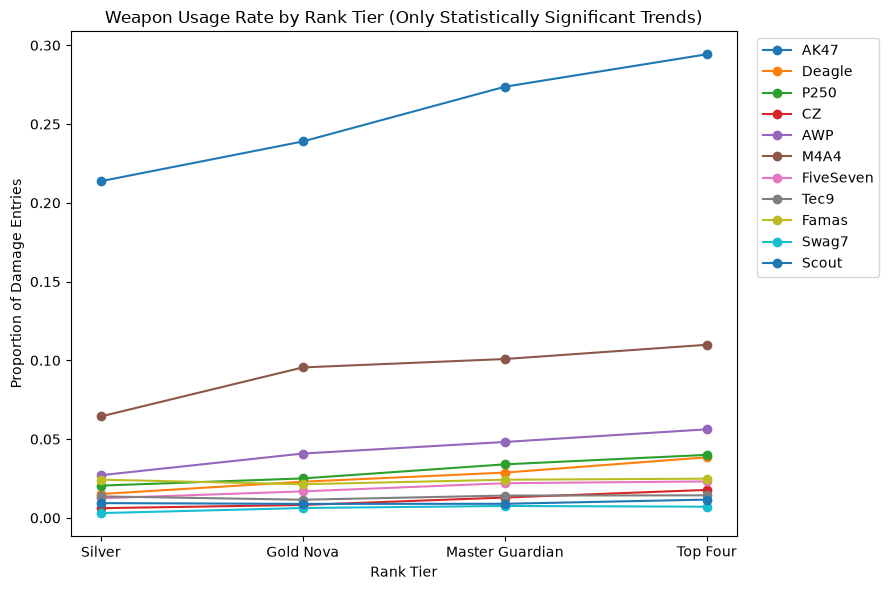

In [72]:
sig_df = res_df[res_df['p_adj'] < 0.05]

fig, ax = plt.subplots(figsize=(9, 6))

for _, row in sig_df.iterrows():
    c = row['counts'].copy()
    c['proportion'] = c['n_hit'] / c['n_total']
    ax.plot(c['att_tier'], c['proportion'], marker='o', label=row['wp'])

ax.set_xlabel('Rank Tier')
ax.set_ylabel('Proportion of Damage Entries')
ax.set_title('Weapon Usage Rate by Rank Tier (Only Statistically Significant Trends)')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig("../images/05_wp_rank.png")
plt.show()

Before checking the inbetween_distance vs att_tier relationship, we need to check if there are a lot of entries where the inbetween_distance value is zero.

In [73]:
df.loc[df["inbetween_distance"] == 0, "wp"].value_counts()

wp
USP       4
AK47      2
AWP       2
M4A1      1
M4A4      1
P90       1
UMP       1
P250      1
Deagle    1
Name: count, dtype: int64

Not much. We can filter that out for ANOVA purposes.

In [74]:
temp_df = df[df["inbetween_distance"] > 0]

temp_df["dist_normalized"], optimal_lambda = stats.boxcox(temp_df["inbetween_distance"])

dist_normalized_1 = temp_df.loc[temp_df["att_tier"] == "Silver", "dist_normalized"]
dist_normalized_2 = temp_df.loc[temp_df["att_tier"] == "Gold Nova", "dist_normalized"]
dist_normalized_3 = temp_df.loc[temp_df["att_tier"] == "Master Guardian", "dist_normalized"]
dist_normalized_4 = temp_df.loc[temp_df["att_tier"] == "Top Four", "dist_normalized"]

f_stat, p_val = stats.f_oneway(
    dist_normalized_1, dist_normalized_2, dist_normalized_3, dist_normalized_4
)
print(f"F-Statistic: {f_stat:.4f}, p-value: {p_val:.4e}")

tukey = pairwise_tukeyhsd(
    endog=temp_df["dist_normalized"],  # The normalized dependent variable
    groups=temp_df["att_tier"],       # The categorical tier groups
    alpha=0.05                            # Significance level
)

print(tukey)

F-Statistic: 590.2125, p-value: 0.0000e+00
         Multiple Comparison of Means - Tukey HSD, FWER=0.05         
     group1          group2     meandiff p-adj  lower   upper  reject
---------------------------------------------------------------------
      Gold Nova Master Guardian   0.3332   0.0  0.2981  0.3683   True
      Gold Nova          Silver  -0.3837   0.0 -0.4965 -0.2708   True
      Gold Nova        Top Four   0.7194   0.0  0.6706  0.7682   True
Master Guardian          Silver  -0.7169   0.0 -0.8294 -0.6043   True
Master Guardian        Top Four   0.3862   0.0  0.3381  0.4343   True
         Silver        Top Four   1.1031   0.0  0.9856  1.2206   True
---------------------------------------------------------------------


In [75]:
dist_silver = df.loc[df["att_tier"] == "Silver", "inbetween_distance"]
dist_gold = df.loc[df["att_tier"] == "Gold Nova", "inbetween_distance"]
dist_master = df.loc[df["att_tier"] == "Master Guardian", "inbetween_distance"]
dist_top = df.loc[df["att_tier"] == "Top Four", "inbetween_distance"]

print(f"Gold Nova --> Master Guardian Mean Difference: {np.mean(dist_master) - np.mean(dist_gold):.4f}")
print(f"Gold Nova --> Silver Mean Difference: {np.mean(dist_silver) - np.mean(dist_gold):.4f}")
print(f"Gold Nova --> Top Four Difference: {np.mean(dist_top) - np.mean(dist_gold):.4f}")
print(f"Master Guardian --> Silver Mean Difference: {np.mean(dist_silver) - np.mean(dist_master):.4f}")
print(f"Master Guardian --> Top Four Mean Difference: {np.mean(dist_top) - np.mean(dist_master):.4f}")
print(f"Silver --> Top Four Difference: {np.mean(dist_top) - np.mean(dist_silver):.4f}")

Gold Nova --> Master Guardian Mean Difference: 24.0908
Gold Nova --> Silver Mean Difference: -20.9549
Gold Nova --> Top Four Difference: 50.8206
Master Guardian --> Silver Mean Difference: -45.0457
Master Guardian --> Top Four Mean Difference: 26.7298
Silver --> Top Four Difference: 71.7755


In [76]:
df.loc[df["att_distance_to_bombsite"] == 0, "att_tier"].value_counts()

att_tier
Silver             0
Gold Nova          0
Master Guardian    0
Top Four           0
Name: count, dtype: int64

In [77]:
temp_df = df[df["att_distance_to_bombsite"] > 0]

temp_df["dist_normalized"], optimal_lambda = stats.boxcox(temp_df["att_distance_to_bombsite"])

dist_normalized_1 = temp_df.loc[temp_df["att_tier"] == "Silver", "dist_normalized"]
dist_normalized_2 = temp_df.loc[temp_df["att_tier"] == "Gold Nova", "dist_normalized"]
dist_normalized_3 = temp_df.loc[temp_df["att_tier"] == "Master Guardian", "dist_normalized"]
dist_normalized_4 = temp_df.loc[temp_df["att_tier"] == "Top Four", "dist_normalized"]

f_stat, p_val = stats.f_oneway(
    dist_normalized_1, dist_normalized_2, dist_normalized_3, dist_normalized_4
)
print(f"F-Statistic: {f_stat:.4f}, p-value: {p_val:.4e}")

tukey = pairwise_tukeyhsd(
    endog=temp_df["dist_normalized"],  # The normalized dependent variable
    groups=temp_df["att_tier"],       # The categorical tier groups
    alpha=0.05                            # Significance level
)

print(tukey)

F-Statistic: 20.1276, p-value: 4.8874e-13
         Multiple Comparison of Means - Tukey HSD, FWER=0.05          
     group1          group2     meandiff p-adj   lower   upper  reject
----------------------------------------------------------------------
      Gold Nova Master Guardian   0.2398 0.0002  0.0928  0.3869   True
      Gold Nova          Silver  -0.2521 0.4677 -0.6987  0.1944  False
      Gold Nova        Top Four   0.6431    0.0   0.407  0.8792   True
Master Guardian          Silver   -0.492 0.0254 -0.9416 -0.0424   True
Master Guardian        Top Four   0.4033 0.0001  0.1616   0.645   True
         Silver        Top Four   0.8953    0.0  0.4092  1.3813   True
----------------------------------------------------------------------


In [78]:
dist_silver = df.loc[df["att_tier"] == "Silver", "att_distance_to_bombsite"]
dist_gold = df.loc[df["att_tier"] == "Gold Nova", "att_distance_to_bombsite"]
dist_master = df.loc[df["att_tier"] == "Master Guardian", "att_distance_to_bombsite"]
dist_top = df.loc[df["att_tier"] == "Top Four", "att_distance_to_bombsite"]

print(f"Gold Nova --> Master Guardian Mean Difference: {np.mean(dist_master) - np.mean(dist_gold):.4f}")
print(f"Gold Nova --> Silver Mean Difference: {np.mean(dist_silver) - np.mean(dist_gold):.4f}")
print(f"Gold Nova --> Top Four Difference: {np.mean(dist_top) - np.mean(dist_gold):.4f}")
print(f"Master Guardian --> Silver Mean Difference: {np.mean(dist_silver) - np.mean(dist_master):.4f}")
print(f"Master Guardian --> Top Four Mean Difference: {np.mean(dist_top) - np.mean(dist_master):.4f}")
print(f"Silver --> Top Four Difference: {np.mean(dist_top) - np.mean(dist_silver):.4f}")

Gold Nova --> Master Guardian Mean Difference: 9.7755
Gold Nova --> Silver Mean Difference: -11.3711
Gold Nova --> Top Four Difference: 22.8884
Master Guardian --> Silver Mean Difference: -21.1466
Master Guardian --> Top Four Mean Difference: 13.1129
Silver --> Top Four Difference: 34.2595


In [79]:
df.loc[df["vic_distance_to_bombsite"] == 0, "att_tier"].value_counts()

att_tier
Silver             0
Gold Nova          0
Master Guardian    0
Top Four           0
Name: count, dtype: int64

In [80]:
temp_df = df[df["vic_distance_to_bombsite"] > 0]

temp_df["dist_normalized"], optimal_lambda = stats.boxcox(temp_df["vic_distance_to_bombsite"])

dist_normalized_1 = temp_df.loc[temp_df["vic_tier"] == "Silver", "dist_normalized"]
dist_normalized_2 = temp_df.loc[temp_df["vic_tier"] == "Gold Nova", "dist_normalized"]
dist_normalized_3 = temp_df.loc[temp_df["vic_tier"] == "Master Guardian", "dist_normalized"]
dist_normalized_4 = temp_df.loc[temp_df["vic_tier"] == "Top Four", "dist_normalized"]

f_stat, p_val = stats.f_oneway(
    dist_normalized_1, dist_normalized_2, dist_normalized_3, dist_normalized_4
)
print(f"F-Statistic: {f_stat:.4f}, p-value: {p_val:.4e}")

tukey = pairwise_tukeyhsd(
    endog=temp_df["dist_normalized"],  # The normalized dependent variable
    groups=temp_df["att_tier"],       # The categorical tier groups
    alpha=0.05                            # Significance level
)

print(tukey)

F-Statistic: 38.2197, p-value: 1.1053e-24
         Multiple Comparison of Means - Tukey HSD, FWER=0.05          
     group1          group2     meandiff p-adj   lower   upper  reject
----------------------------------------------------------------------
      Gold Nova Master Guardian   0.3353    0.0  0.1842  0.4865   True
      Gold Nova          Silver  -0.1747 0.7624 -0.6337  0.2844  False
      Gold Nova        Top Four   0.8705    0.0  0.6278  1.1132   True
Master Guardian          Silver    -0.51 0.0237 -0.9722 -0.0478   True
Master Guardian        Top Four   0.5352    0.0  0.2866  0.7837   True
         Silver        Top Four   1.0451    0.0  0.5455  1.5448   True
----------------------------------------------------------------------


In [81]:
dist_silver = df.loc[df["att_tier"] == "Silver", "vic_distance_to_bombsite"]
dist_gold = df.loc[df["att_tier"] == "Gold Nova", "vic_distance_to_bombsite"]
dist_master = df.loc[df["att_tier"] == "Master Guardian", "vic_distance_to_bombsite"]
dist_top = df.loc[df["att_tier"] == "Top Four", "vic_distance_to_bombsite"]

print(f"Gold Nova --> Master Guardian Mean Difference: {np.mean(dist_master) - np.mean(dist_gold):.4f}")
print(f"Gold Nova --> Silver Mean Difference: {np.mean(dist_silver) - np.mean(dist_gold):.4f}")
print(f"Gold Nova --> Top Four Difference: {np.mean(dist_top) - np.mean(dist_gold):.4f}")
print(f"Master Guardian --> Silver Mean Difference: {np.mean(dist_silver) - np.mean(dist_master):.4f}")
print(f"Master Guardian --> Top Four Mean Difference: {np.mean(dist_top) - np.mean(dist_master):.4f}")
print(f"Silver --> Top Four Difference: {np.mean(dist_top) - np.mean(dist_silver):.4f}")

Gold Nova --> Master Guardian Mean Difference: 12.0902
Gold Nova --> Silver Mean Difference: -11.7522
Gold Nova --> Top Four Difference: 30.1983
Master Guardian --> Silver Mean Difference: -23.8424
Master Guardian --> Top Four Mean Difference: 18.1081
Silver --> Top Four Difference: 41.9505
